# Imports and Shared Setup

In [3]:
!pip install pandas numpy scikit-learn matplotlib tensorflow transformers datasets evaluate accelerate torch
!pip uninstall -y torchvision

In [120]:
import re
import time
import copy
import itertools
import random
import numpy as np
import pandas as pd
import kagglehub
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay, precision_recall_fscore_support

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

In [5]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

TEXT_COL = "text"
LABEL_COL = "sentiment"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


# Dataset

In [7]:
path = kagglehub.dataset_download("abhi8923shriv/sentiment-analysis-dataset")

print("Path to dataset files:", path)

train_df = pd.read_csv("/kaggle/input/sentiment-analysis-dataset/train.csv", encoding="latin-1")
test_df = pd.read_csv("/kaggle/input/sentiment-analysis-dataset/test.csv", encoding="latin-1")

train_df = train_df[[TEXT_COL, LABEL_COL]].dropna()
test_df = test_df[[TEXT_COL, LABEL_COL]].dropna()

label_map = {"negative": 0, "neutral": 1, "positive": 2}
train_df[LABEL_COL] = train_df[LABEL_COL].map(label_map)
test_df[LABEL_COL] = test_df[LABEL_COL].map(label_map)

num_classes = train_df[LABEL_COL].nunique()

print(train_df.head())
print()
print(test_df.head())

Using Colab cache for faster access to the 'sentiment-analysis-dataset' dataset.
Path to dataset files: /kaggle/input/sentiment-analysis-dataset
                                                text  sentiment
0                I`d have responded, if I were going          1
1      Sooo SAD I will miss you here in San Diego!!!          0
2                          my boss is bullying me...          0
3                     what interview! leave me alone          0
4   Sons of ****, why couldn`t they put them on t...          0

                                                text  sentiment
0  Last session of the day  http://twitpic.com/67ezh          1
1   Shanghai is also really exciting (precisely -...          2
2  Recession hit Veronique Branquinho, she has to...          0
3                                        happy bday!          2
4             http://twitpic.com/4w75p - I like it!!          2


## Train/Val Split

In [8]:
train_df, val_df = train_test_split(
    train_df,
    test_size=0.30,
    random_state=SEED,
    stratify=train_df[LABEL_COL]
)

print(f"Training dataset size: {len(train_df)}")
print(f"Validation dataset size: {len(val_df)}")
print(f"Testing dataset size: {len(test_df)}")

Training dataset size: 19236
Validation dataset size: 8244
Testing dataset size: 3534


# TF-IDF + Logistic Regression (Baseline)

In [9]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

## Model

In [10]:
tfidf_logreg_pipeline = Pipeline([
    ("tfidf", TfidfVectorizer()),
    ("classifier", LogisticRegression(
        max_iter=1000,
        random_state=SEED
    ))
])

## Optimization and Training

In [11]:
tfidf_param_dist = {
    "tfidf__lowercase": [True],
    "tfidf__max_features": [20000, 50000, 100000],
    "tfidf__ngram_range": [(1, 1), (1, 2)],
    "tfidf__min_df": [1, 2, 5],
    "tfidf__sublinear_tf": [True, False],
    "classifier__C": [0.1, 0.5, 1.0, 3.0, 10.0],
    "classifier__class_weight": [None, "balanced"],
    "classifier__solver": ["liblinear", "lbfgs"]
}

In [12]:
tfidf_search = RandomizedSearchCV(
    estimator=tfidf_logreg_pipeline,
    param_distributions=tfidf_param_dist,
    n_iter=30,
    cv=3,
    verbose=2,
    random_state=SEED,
    n_jobs=-1
)

In [14]:
tfidf_search.fit(
    train_df[TEXT_COL],
    train_df[LABEL_COL]
)

best_tfidf_logreg_model = tfidf_search.best_estimator_

Fitting 3 folds for each of 30 candidates, totalling 90 fits


## Evaluation

In [15]:
val_preds = best_tfidf_logreg_model.predict(val_df[TEXT_COL])

print("Validation Accuracy:", accuracy_score(val_df[LABEL_COL], val_preds))
print("Validation Macro-F1:", f1_score(val_df[LABEL_COL], val_preds, average="macro"))

print(classification_report(
    val_df[LABEL_COL],
    val_preds,
    target_names=["negative", "neutral", "positive"]
))

Validation Accuracy: 0.6889859291606016
Validation Macro-F1: 0.6900407134345903
              precision    recall  f1-score   support

    negative       0.70      0.62      0.66      2334
     neutral       0.63      0.72      0.67      3335
    positive       0.77      0.71      0.74      2575

    accuracy                           0.69      8244
   macro avg       0.70      0.68      0.69      8244
weighted avg       0.69      0.69      0.69      8244



# Tokenizer for RNN and BiLSTM

In [17]:
from collections import Counter

def clean_tweet(text):
    text = text.lower()
    text = re.sub(r"http\S+|www\S+", "<url>", text)
    text = re.sub(r"@\w+", "<user>", text)
    text = re.sub(r"#", "", text)
    text = re.sub(r"[^a-zA-Z0-9!?.,'<>\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

def tokenize(text):
    return clean_tweet(text).split()

In [18]:
counter = Counter()

for text in train_df[TEXT_COL]:
    counter.update(tokenize(text))

MAX_VOCAB_SIZE = 30000
MIN_FREQ = 2

special_tokens = ["<pad>", "<unk>"]

vocab_tokens = [
    token for token, freq in counter.most_common(MAX_VOCAB_SIZE)
    if freq >= MIN_FREQ
]

itos = special_tokens + vocab_tokens
stoi = {token: idx for idx, token in enumerate(itos)}

PAD_IDX = stoi["<pad>"]
UNK_IDX = stoi["<unk>"]

vocab_size = len(itos)

print("Vocab size:", vocab_size)

Vocab size: 10205


## Dataset Class

In [19]:
class TweetDataset(Dataset):
    def __init__(self, dataframe, text_col, label_col, stoi, max_len=64):
        self.texts = dataframe[text_col].tolist()
        self.labels = dataframe[label_col].tolist()
        self.stoi = stoi
        self.max_len = max_len

    def encode_text(self, text):
        tokens = tokenize(text)
        ids = [self.stoi.get(token, UNK_IDX) for token in tokens]

        if len(ids) < self.max_len:
            ids = ids + [PAD_IDX] * (self.max_len - len(ids))
        else:
            ids = ids[:self.max_len]

        return ids

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        input_ids = self.encode_text(self.texts[idx])
        label = self.labels[idx]

        return {
            "input_ids": torch.tensor(input_ids, dtype=torch.long),
            "label": torch.tensor(label, dtype=torch.long)
        }

In [20]:
MAX_LEN = 64
BATCH_SIZE = 64

train_dataset = TweetDataset(train_df, TEXT_COL, LABEL_COL, stoi, max_len=MAX_LEN)
val_dataset = TweetDataset(val_df, TEXT_COL, LABEL_COL, stoi, max_len=MAX_LEN)
test_dataset = TweetDataset(test_df, TEXT_COL, LABEL_COL, stoi, max_len=MAX_LEN)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE)

# Shared Training Utilities for RNN and BiLSTM

## Train One Epoch

In [43]:
def train_one_epoch(model, dataloader, optimizer, criterion, device):
    model.train()

    total_loss = 0
    all_preds = []
    all_labels = []

    for batch in dataloader:
        input_ids = batch["input_ids"].to(device)
        labels = batch["label"].to(device)

        optimizer.zero_grad()

        logits = model(input_ids)
        loss = criterion(logits, labels)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        preds = torch.argmax(logits, dim=1)

        all_preds.extend(preds.detach().cpu().numpy())
        all_labels.extend(labels.detach().cpu().numpy())

    avg_loss = total_loss / len(dataloader)
    accuracy = accuracy_score(all_labels, all_preds)
    macro_f1 = f1_score(all_labels, all_preds, average="macro")

    return avg_loss, accuracy, macro_f1

## Evaluate Model

In [44]:
def evaluate_model(model, dataloader, criterion, device):
    model.eval()

    total_loss = 0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for batch in dataloader:
            input_ids = batch["input_ids"].to(device)
            labels = batch["label"].to(device)

            logits = model(input_ids)
            loss = criterion(logits, labels)

            total_loss += loss.item()

            preds = torch.argmax(logits, dim=1)

            all_preds.extend(preds.detach().cpu().numpy())
            all_labels.extend(labels.detach().cpu().numpy())

    avg_loss = total_loss / len(dataloader)
    accuracy = accuracy_score(all_labels, all_preds)
    macro_f1 = f1_score(all_labels, all_preds, average="macro")

    return avg_loss, accuracy, macro_f1, all_preds, all_labels

## Train Model

In [45]:
def train_neural_model(model, train_loader, val_loader, epochs=5, lr=1e-3):
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    history = []

    for epoch in range(epochs):
        train_loss, train_acc, train_f1 = train_one_epoch(
            model, train_loader, optimizer, criterion, device
        )

        val_loss, val_acc, val_f1, _, _ = evaluate_model(
            model, val_loader, criterion, device
        )

        history.append({
            "epoch": epoch + 1,
            "train_loss": train_loss,
            "train_acc": train_acc,
            "train_macro_f1": train_f1,
            "val_loss": val_loss,
            "val_acc": val_acc,
            "val_macro_f1": val_f1
        })

        print(
            f"Epoch {epoch+1}/{epochs} | "
            f"Train Loss: {train_loss:.4f} | "
            f"Train Acc: {train_acc:.4f} | "
            f"Train F1: {train_f1:.4f} | "
            f"Val Loss: {val_loss:.4f} | "
            f"Val Acc: {val_acc:.4f} | "
            f"Val F1: {val_f1:.4f}"
        )

    return pd.DataFrame(history)

## Hyperparameter Optimization Utilities

In [52]:
def create_param_combinations(param_grid):
    keys = list(param_grid.keys())
    values = list(param_grid.values())

    combinations = []

    for combo in itertools.product(*values):
        param_dict = dict(zip(keys, combo))
        combinations.append(param_dict)

    return combinations

In [53]:
def build_dataloaders(max_len, batch_size):
    train_dataset = TweetDataset(
        train_df,
        TEXT_COL,
        LABEL_COL,
        stoi,
        max_len=max_len
    )

    val_dataset = TweetDataset(
        val_df,
        TEXT_COL,
        LABEL_COL,
        stoi,
        max_len=max_len
    )

    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True
    )

    val_loader = DataLoader(
        val_dataset,
        batch_size=batch_size,
        shuffle=False
    )

    return train_loader, val_loader

In [60]:
def build_test_loader(max_len, batch_size):
    test_dataset = TweetDataset(
        test_df,
        TEXT_COL,
        LABEL_COL,
        stoi,
        max_len=max_len
    )

    test_loader = DataLoader(
        test_dataset,
        batch_size=batch_size,
        shuffle=False
    )

    return test_loader

In [54]:
def train_with_early_stopping(
    model,
    train_loader,
    val_loader,
    lr,
    epochs=10,
    patience=3,
    device="cpu"
):
    criterion = nn.CrossEntropyLoss()

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=lr,
        weight_decay=1e-4
    )

    best_val_f1 = -1.0
    best_val_loss = float("inf")
    best_model_state = None
    best_epoch = 0

    history = []

    patience_counter = 0

    for epoch in range(1, epochs + 1):
        train_loss, train_acc, train_f1 = train_one_epoch(
            model,
            train_loader,
            optimizer,
            criterion,
            device
        )

        val_loss, val_acc, val_f1, _, _ = evaluate_model(
            model,
            val_loader,
            criterion,
            device
        )

        history.append({
            "epoch": epoch,
            "train_loss": train_loss,
            "train_accuracy": train_acc,
            "train_macro_f1": train_f1,
            "val_loss": val_loss,
            "val_accuracy": val_acc,
            "val_macro_f1": val_f1
        })

        improved = val_f1 > best_val_f1

        if improved:
            best_val_f1 = val_f1
            best_val_loss = val_loss
            best_model_state = copy.deepcopy(model.state_dict())
            best_epoch = epoch
            patience_counter = 0
        else:
            patience_counter += 1

        print(
            f"Epoch {epoch:02d} | "
            f"Train F1: {train_f1:.4f} | "
            f"Val F1: {val_f1:.4f} | "
            f"Val Acc: {val_acc:.4f} | "
            f"Val Loss: {val_loss:.4f}"
        )

        if patience_counter >= patience:
            print("Early stopping triggered.")
            break

    model.load_state_dict(best_model_state)

    return {
        "model": model,
        "best_model_state": best_model_state,
        "best_val_f1": best_val_f1,
        "best_val_loss": best_val_loss,
        "best_epoch": best_epoch,
        "history": pd.DataFrame(history)
    }

In [55]:
def run_neural_grid_search(
    model_name,
    model_class,
    param_combinations,
    vocab_size,
    num_classes,
    pad_idx,
    device,
    epochs=10,
    patience=3
):
    results = []
    best_overall_f1 = -1.0
    best_overall = None

    total_runs = len(param_combinations)

    for run_idx, params in enumerate(param_combinations, start=1):
        print("=" * 80)
        print(f"{model_name} Grid Search Run {run_idx}/{total_runs}")
        print(params)
        print("=" * 80)

        start_time = time.time()

        train_loader, val_loader = build_dataloaders(
            max_len=params["max_len"],
            batch_size=params["batch_size"]
        )

        if model_name == "RNN":
            model = model_class(
                vocab_size=vocab_size,
                embedding_dim=params["embedding_dim"],
                hidden_dim=params["hidden_dim"],
                num_classes=num_classes,
                pad_idx=pad_idx,
                dropout=params["dropout"]
            ).to(device)

        elif model_name == "BiLSTM":
            model = model_class(
                vocab_size=vocab_size,
                embedding_dim=params["embedding_dim"],
                hidden_dim=params["hidden_dim"],
                num_classes=num_classes,
                pad_idx=pad_idx,
                num_layers=params["num_layers"],
                dropout=params["dropout"]
            ).to(device)

        else:
            raise ValueError("model_name must be either 'RNN' or 'BiLSTM'.")

        training_output = train_with_early_stopping(
            model=model,
            train_loader=train_loader,
            val_loader=val_loader,
            lr=params["lr"],
            epochs=epochs,
            patience=patience,
            device=device
        )

        elapsed_time = time.time() - start_time

        result_row = {
            "model_name": model_name,
            "run": run_idx,
            "best_val_f1": training_output["best_val_f1"],
            "best_val_loss": training_output["best_val_loss"],
            "best_epoch": training_output["best_epoch"],
            "training_time_seconds": elapsed_time,
            **params
        }

        results.append(result_row)

        if training_output["best_val_f1"] > best_overall_f1:
            best_overall_f1 = training_output["best_val_f1"]

            best_overall = {
                "model_name": model_name,
                "params": params,
                "model": training_output["model"],
                "best_model_state": training_output["best_model_state"],
                "best_val_f1": training_output["best_val_f1"],
                "best_val_loss": training_output["best_val_loss"],
                "best_epoch": training_output["best_epoch"],
                "history": training_output["history"]
            }

        print(
            f"Finished run {run_idx}/{total_runs} | "
            f"Best Val F1: {training_output['best_val_f1']:.4f} | "
            f"Time: {elapsed_time:.2f}s"
        )

    results_df = pd.DataFrame(results)
    results_df = results_df.sort_values(
        by="best_val_f1",
        ascending=False
    ).reset_index(drop=True)

    return best_overall, results_df

# Vanilla RNN

## Architecture

In [56]:
class VanillaRNNClassifier(nn.Module):
    def __init__(
        self,
        vocab_size,
        embedding_dim,
        hidden_dim,
        num_classes,
        pad_idx,
        dropout=0.3
    ):
        super().__init__()

        self.embedding = nn.Embedding(
            num_embeddings=vocab_size,
            embedding_dim=embedding_dim,
            padding_idx=pad_idx
        )

        self.rnn = nn.RNN(
            input_size=embedding_dim,
            hidden_size=hidden_dim,
            batch_first=True
        )

        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim, num_classes)

    def forward(self, input_ids):
        embedded = self.embedding(input_ids)

        output, hidden = self.rnn(embedded)

        final_hidden = hidden[-1]

        final_hidden = self.dropout(final_hidden)
        logits = self.fc(final_hidden)

        return logits

## Optimization and Training

In [57]:
rnn_param_grid = {
    "embedding_dim": [100, 128],
    "hidden_dim": [64, 128],
    "dropout": [0.2, 0.4],
    "lr": [1e-3, 5e-4],
    "batch_size": [64],
    "max_len": [64]
}

rnn_combinations = create_param_combinations(rnn_param_grid)

In [58]:
best_rnn, rnn_grid_results = run_neural_grid_search(
    model_name="RNN",
    model_class=VanillaRNNClassifier,
    param_combinations=rnn_combinations,
    vocab_size=vocab_size,
    num_classes=num_classes,
    pad_idx=PAD_IDX,
    device=device,
    epochs=10,
    patience=3
)

RNN Grid Search Run 1/16
{'embedding_dim': 100, 'hidden_dim': 64, 'dropout': 0.2, 'lr': 0.001, 'batch_size': 64, 'max_len': 64}
Epoch 01 | Train F1: 0.2014 | Val F1: 0.1920 | Val Acc: 0.4045 | Val Loss: 1.0871
Epoch 02 | Train F1: 0.1920 | Val F1: 0.1920 | Val Acc: 0.4045 | Val Loss: 1.0874
Epoch 03 | Train F1: 0.1920 | Val F1: 0.1920 | Val Acc: 0.4045 | Val Loss: 1.0873
Epoch 04 | Train F1: 0.1920 | Val F1: 0.1920 | Val Acc: 0.4045 | Val Loss: 1.0870
Early stopping triggered.
Finished run 1/16 | Best Val F1: 0.1920 | Time: 6.96s
RNN Grid Search Run 2/16
{'embedding_dim': 100, 'hidden_dim': 64, 'dropout': 0.2, 'lr': 0.0005, 'batch_size': 64, 'max_len': 64}
Epoch 01 | Train F1: 0.2029 | Val F1: 0.1920 | Val Acc: 0.4045 | Val Loss: 1.0875
Epoch 02 | Train F1: 0.1921 | Val F1: 0.1920 | Val Acc: 0.4045 | Val Loss: 1.0868
Epoch 03 | Train F1: 0.1920 | Val F1: 0.1920 | Val Acc: 0.4045 | Val Loss: 1.0870
Epoch 04 | Train F1: 0.1920 | Val F1: 0.1920 | Val Acc: 0.4045 | Val Loss: 1.0869
Early s

## Evaluating Best Model

In [62]:
rnn_test_loader = build_test_loader(
    max_len=best_rnn["params"]["max_len"],
    batch_size=best_rnn["params"]["batch_size"]
)

criterion = nn.CrossEntropyLoss()

rnn_test_loss, rnn_test_acc, rnn_test_f1, rnn_test_preds, rnn_test_labels = evaluate_model(
    best_rnn["model"],
    rnn_test_loader,
    criterion,
    device
)

print("Best RNN Test Loss:", rnn_test_loss)
print("Best RNN Test Accuracy:", rnn_test_acc)
print("Best RNN Test Macro-F1:", rnn_test_f1)

print(classification_report(
    rnn_test_labels,
    rnn_test_preds,
    target_names=["negative", "neutral", "positive"]
))

Best RNN Test Loss: 1.092065236398152
Best RNN Test Accuracy: 0.3737973967176004
Best RNN Test Macro-F1: 0.2864156397759554
              precision    recall  f1-score   support

    negative       0.00      0.00      0.00      1001
     neutral       0.41      0.57      0.48      1430
    positive       0.33      0.46      0.38      1103

    accuracy                           0.37      3534
   macro avg       0.25      0.34      0.29      3534
weighted avg       0.27      0.37      0.31      3534



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [71]:
torch.save(
    {
        "model_state_dict": best_rnn["best_model_state"],
        "params": best_rnn["params"],
        "best_val_f1": best_rnn["best_val_f1"],
        "best_val_loss": best_rnn["best_val_loss"],
        "best_epoch": best_rnn["best_epoch"],
        "stoi": stoi,
        "itos": itos
    },
    "best_rnn_model.pt"
)

# BiLSTM

## Architecture

In [64]:
class BiLSTMClassifier(nn.Module):
    def __init__(
        self,
        vocab_size,
        embedding_dim,
        hidden_dim,
        num_classes,
        pad_idx,
        num_layers=1,
        dropout=0.3
    ):
        super().__init__()

        self.embedding = nn.Embedding(
            num_embeddings=vocab_size,
            embedding_dim=embedding_dim,
            padding_idx=pad_idx
        )

        self.lstm = nn.LSTM(
            input_size=embedding_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=True,
            dropout=dropout if num_layers > 1 else 0
        )

        self.dropout = nn.Dropout(dropout)

        self.fc = nn.Linear(hidden_dim * 2, num_classes)

    def forward(self, input_ids):
        embedded = self.embedding(input_ids)

        output, (hidden, cell) = self.lstm(embedded)

        forward_hidden = hidden[-2]
        backward_hidden = hidden[-1]

        final_hidden = torch.cat((forward_hidden, backward_hidden), dim=1)

        final_hidden = self.dropout(final_hidden)
        logits = self.fc(final_hidden)

        return logits

## Optimization and Training

In [66]:
bilstm_param_grid = {
    "embedding_dim": [100, 128],
    "hidden_dim": [64, 128],
    "dropout": [0.2, 0.4],
    "lr": [1e-3, 5e-4],
    "batch_size": [64],
    "max_len": [64],
    "num_layers": [1, 2]
}

bilstm_combinations = create_param_combinations(bilstm_param_grid)

In [67]:
best_bilstm, bilstm_grid_results = run_neural_grid_search(
    model_name="BiLSTM",
    model_class=BiLSTMClassifier,
    param_combinations=bilstm_combinations,
    vocab_size=vocab_size,
    num_classes=num_classes,
    pad_idx=PAD_IDX,
    device=device,
    epochs=10,
    patience=3
)

BiLSTM Grid Search Run 1/32
{'embedding_dim': 100, 'hidden_dim': 64, 'dropout': 0.2, 'lr': 0.001, 'batch_size': 64, 'max_len': 64, 'num_layers': 1}
Epoch 01 | Train F1: 0.4320 | Val F1: 0.5153 | Val Acc: 0.5415 | Val Loss: 0.9401
Epoch 02 | Train F1: 0.5962 | Val F1: 0.5998 | Val Acc: 0.5972 | Val Loss: 0.8729
Epoch 03 | Train F1: 0.6702 | Val F1: 0.6234 | Val Acc: 0.6264 | Val Loss: 0.8394
Epoch 04 | Train F1: 0.7225 | Val F1: 0.6354 | Val Acc: 0.6365 | Val Loss: 0.8178
Epoch 05 | Train F1: 0.7671 | Val F1: 0.6465 | Val Acc: 0.6481 | Val Loss: 0.8305
Epoch 06 | Train F1: 0.8077 | Val F1: 0.6548 | Val Acc: 0.6526 | Val Loss: 0.8958
Epoch 07 | Train F1: 0.8407 | Val F1: 0.6529 | Val Acc: 0.6510 | Val Loss: 0.9382
Epoch 08 | Train F1: 0.8673 | Val F1: 0.6582 | Val Acc: 0.6568 | Val Loss: 0.9946
Epoch 09 | Train F1: 0.8911 | Val F1: 0.6546 | Val Acc: 0.6531 | Val Loss: 1.0916
Epoch 10 | Train F1: 0.9115 | Val F1: 0.6514 | Val Acc: 0.6494 | Val Loss: 1.1898
Finished run 1/32 | Best Val F1:

## Evaluating Best Model

In [69]:
bilstm_test_loader = build_test_loader(
    max_len=best_bilstm["params"]["max_len"],
    batch_size=best_bilstm["params"]["batch_size"]
)

bilstm_test_loss, bilstm_test_acc, bilstm_test_f1, bilstm_test_preds, bilstm_test_labels = evaluate_model(
    best_bilstm["model"],
    bilstm_test_loader,
    criterion,
    device
)

print("Best BiLSTM Test Loss:", bilstm_test_loss)
print("Best BiLSTM Test Accuracy:", bilstm_test_acc)
print("Best BiLSTM Test Macro-F1:", bilstm_test_f1)

print(classification_report(
    bilstm_test_labels,
    bilstm_test_preds,
    target_names=["negative", "neutral", "positive"]
))

Best BiLSTM Test Loss: 0.8563080493892942
Best BiLSTM Test Accuracy: 0.6621392190152802
Best BiLSTM Test Macro-F1: 0.6633758491031337
              precision    recall  f1-score   support

    negative       0.67      0.60      0.63      1001
     neutral       0.61      0.68      0.65      1430
    positive       0.73      0.69      0.71      1103

    accuracy                           0.66      3534
   macro avg       0.67      0.66      0.66      3534
weighted avg       0.67      0.66      0.66      3534



In [70]:
torch.save(
    {
        "model_state_dict": best_bilstm["best_model_state"],
        "params": best_bilstm["params"],
        "best_val_f1": best_bilstm["best_val_f1"],
        "best_val_loss": best_bilstm["best_val_loss"],
        "best_epoch": best_bilstm["best_epoch"],
        "stoi": stoi,
        "itos": itos
    },
    "best_bilstm_model.pt"
)

# DistilBERT

In [73]:
from transformers import DistilBertTokenizerFast
from transformers import DistilBertForSequenceClassification
from transformers import Trainer, TrainingArguments
from datasets import Dataset

## Tokenizer

In [74]:
distilbert_tokenizer = DistilBertTokenizerFast.from_pretrained("distilbert-base-uncased")

def tokenize_distilbert(batch):
    return distilbert_tokenizer(
        batch[TEXT_COL],
        padding="max_length",
        truncation=True,
        max_length=128
    )

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

## HuggingFace Datasets

In [75]:
def create_huggingface_dataset(dataframe):

  dataset = Dataset.from_pandas(dataframe[[TEXT_COL, LABEL_COL]].reset_index(drop=True))

  dataset = dataset.rename_column(LABEL_COL, "labels")

  dataset = dataset.map(tokenize_distilbert, batched=True)

  dataset.set_format(
    type="torch",
    columns=["input_ids", "attention_mask", "labels"]
  )

  return dataset


train_hf = create_huggingface_dataset(train_df)
val_hf = create_huggingface_dataset(val_df)
test_hf = create_huggingface_dataset(test_df)

Map:   0%|          | 0/19236 [00:00<?, ? examples/s]

Map:   0%|          | 0/8244 [00:00<?, ? examples/s]

Map:   0%|          | 0/3534 [00:00<?, ? examples/s]

## Model

In [76]:
distilbert_model = DistilBertForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels=num_classes
)

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


## Metric Function

In [77]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)

    return {
        "accuracy": accuracy_score(labels, preds),
        "macro_f1": f1_score(labels, preds, average="macro"),
        "weighted_f1": f1_score(labels, preds, average="weighted")
    }

## Training and Validation

In [78]:
training_args = TrainingArguments(
    output_dir="./distilbert_sentiment_results",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    num_train_epochs=3,
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="macro_f1",
    greater_is_better=True,
    logging_dir="./distilbert_logs",
    logging_steps=100,
    seed=SEED,
    report_to="none"
)

[transformers] `logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


In [79]:
distilbert_trainer = Trainer(
    model=distilbert_model,
    args=training_args,
    train_dataset=train_hf,
    eval_dataset=val_hf,
    compute_metrics=compute_metrics
)

distilbert_trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,Macro F1,Weighted F1
1,0.535097,0.520738,0.788937,0.792360,0.789636
2,0.424844,0.538261,0.788937,0.792361,0.788832
3,0.327164,0.607041,0.787603,0.791000,0.787244


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=3609, training_loss=0.4521525563477611, metrics={'train_runtime': 322.9424, 'train_samples_per_second': 178.694, 'train_steps_per_second': 11.175, 'total_flos': 1911141242293248.0, 'train_loss': 0.4521525563477611, 'epoch': 3.0})

In [80]:
distilbert_val_results = distilbert_trainer.evaluate(val_hf)
print(distilbert_val_results)

Training Loss,Validation Loss,Epoch,Accuracy,Macro F1,Weighted F1
0.327164,0.538261,3,0.788937,0.792361,0.788832


{'eval_loss': 0.5382612943649292, 'eval_accuracy': 0.7889374090247453, 'eval_macro_f1': 0.7923612049620048, 'eval_weighted_f1': 0.7888324815117305}


## Evaluation

In [81]:
distilbert_test_results = distilbert_trainer.evaluate(test_hf)
print(distilbert_test_results)

Training Loss,Validation Loss,Epoch,Accuracy,Macro F1,Weighted F1
0.327164,0.526683,3,0.792586,0.796182,0.792559


{'eval_loss': 0.5266831517219543, 'eval_accuracy': 0.7925863044708545, 'eval_macro_f1': 0.7961816679926299, 'eval_weighted_f1': 0.7925586106932728}


In [82]:
distilbert_trainer.save_model("./distilbert_model")
distilbert_tokenizer.save_pretrained("./distilbert_model")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('./distilbert_model/tokenizer_config.json',
 './distilbert_model/tokenizer.json')

In [83]:
!zip -r ./distilbert_model.zip ./distilbert_model


  adding: distilbert_model/ (stored 0%)
  adding: distilbert_model/model.safetensors (deflated 8%)
  adding: distilbert_model/tokenizer.json (deflated 71%)
  adding: distilbert_model/training_args.bin (deflated 53%)
  adding: distilbert_model/config.json (deflated 52%)
  adding: distilbert_model/tokenizer_config.json (deflated 43%)


# Model Comparisons

## Helpers

In [116]:
label_names = ["negative", "neutral", "positive"]

In [96]:
def predict_tfidf_logreg(model, dataframe):
    texts = dataframe[TEXT_COL].tolist()
    preds = model.predict(texts)
    return np.array(preds)

In [97]:
def predict_torch_model(model, dataloader, device):
    model.eval()

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for batch in dataloader:
            input_ids = batch["input_ids"].to(device)
            labels = batch["label"].to(device)

            logits = model(input_ids)
            preds = torch.argmax(logits, dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    return np.array(all_preds), np.array(all_labels)

In [98]:
def predict_distilbert(model, tokenizer, dataframe, batch_size=32, max_length=128):
    model.eval()

    texts = dataframe[TEXT_COL].tolist()
    labels = dataframe[LABEL_COL].to_numpy()

    all_preds = []

    with torch.no_grad():
        for i in range(0, len(texts), batch_size):
            batch_texts = texts[i:i + batch_size]

            encoded = tokenizer(
                batch_texts,
                padding=True,
                truncation=True,
                max_length=max_length,
                return_tensors="pt"
            )

            encoded = {
                key: value.to(device)
                for key, value in encoded.items()
            }

            outputs = model(**encoded)
            logits = outputs.logits
            preds = torch.argmax(logits, dim=1)

            all_preds.extend(preds.cpu().numpy())

    return np.array(all_preds), labels

In [99]:
def compute_classification_metrics(y_true, y_pred, model_name):
    accuracy = accuracy_score(y_true, y_pred)

    precision_macro, recall_macro, f1_macro, _ = precision_recall_fscore_support(
        y_true,
        y_pred,
        average="macro",
        zero_division=0
    )

    precision_weighted, recall_weighted, f1_weighted, _ = precision_recall_fscore_support(
        y_true,
        y_pred,
        average="weighted",
        zero_division=0
    )

    return {
        "model": model_name,
        "accuracy": accuracy,
        "macro_precision": precision_macro,
        "macro_recall": recall_macro,
        "macro_f1": f1_macro,
        "weighted_precision": precision_weighted,
        "weighted_recall": recall_weighted,
        "weighted_f1": f1_weighted
    }

In [100]:
def inspect_checkpoint(path):
    checkpoint = torch.load(path, map_location="cpu")

    print("Checkpoint keys:")
    print(checkpoint.keys())

    print("\nSaved params:")
    print(checkpoint.get("params", "No params found"))

    print("\nBest validation F1:")
    print(checkpoint.get("best_val_f1", "Not found"))

    print("\nBest validation loss:")
    print(checkpoint.get("best_val_loss", "Not found"))

    print("\nBest epoch:")
    print(checkpoint.get("best_epoch", "Not found"))

    if "model_state_dict" in checkpoint:
        print("\nState dict parameter shapes:")
        for key, value in checkpoint["model_state_dict"].items():
            print(key, tuple(value.shape))

    return checkpoint

In [101]:
rnn_checkpoint = inspect_checkpoint("best_rnn_model.pt")
bilstm_checkpoint = inspect_checkpoint("best_bilstm_model.pt")

Checkpoint keys:
dict_keys(['model_state_dict', 'params', 'best_val_f1', 'best_val_loss', 'best_epoch', 'stoi', 'itos'])

Saved params:
{'embedding_dim': 128, 'hidden_dim': 128, 'dropout': 0.4, 'lr': 0.001, 'batch_size': 64, 'max_len': 64}

Best validation F1:
0.28959932910401737

Best validation loss:
1.0911121793495593

Best epoch:
7

State dict parameter shapes:
embedding.weight (10205, 128)
rnn.weight_ih_l0 (128, 128)
rnn.weight_hh_l0 (128, 128)
rnn.bias_ih_l0 (128,)
rnn.bias_hh_l0 (128,)
fc.weight (3, 128)
fc.bias (3,)
Checkpoint keys:
dict_keys(['model_state_dict', 'params', 'best_val_f1', 'best_val_loss', 'best_epoch', 'stoi', 'itos'])

Saved params:
{'embedding_dim': 128, 'hidden_dim': 128, 'dropout': 0.4, 'lr': 0.001, 'batch_size': 64, 'max_len': 64, 'num_layers': 2}

Best validation F1:
0.6617280883878857

Best validation loss:
0.8685947682044303

Best epoch:
5

State dict parameter shapes:
embedding.weight (10205, 128)
lstm.weight_ih_l0 (512, 128)
lstm.weight_hh_l0 (512, 128

## Loading Vanilla RNN

In [102]:
rnn_checkpoint = torch.load("best_rnn_model.pt", map_location=device)

rnn_params = rnn_checkpoint["params"]
rnn_stoi = rnn_checkpoint["stoi"]
rnn_itos = rnn_checkpoint["itos"]

rnn_pad_idx = rnn_stoi["<pad>"]
rnn_vocab_size = len(rnn_itos)

rnn_model = VanillaRNNClassifier(
    vocab_size=rnn_vocab_size,
    embedding_dim=rnn_params["embedding_dim"],
    hidden_dim=rnn_params["hidden_dim"],
    num_classes=rnn_params.get("num_classes", 3),
    pad_idx=rnn_pad_idx,
    dropout=rnn_params.get("dropout", 0.3)
).to(device)

rnn_model.load_state_dict(rnn_checkpoint["model_state_dict"])
rnn_model.eval()

VanillaRNNClassifier(
  (embedding): Embedding(10205, 128, padding_idx=0)
  (rnn): RNN(128, 128, batch_first=True)
  (dropout): Dropout(p=0.4, inplace=False)
  (fc): Linear(in_features=128, out_features=3, bias=True)
)

## Loading BiLSTM

In [103]:
bilstm_checkpoint = torch.load("best_bilstm_model.pt", map_location=device)

bilstm_params = bilstm_checkpoint["params"]
bilstm_stoi = bilstm_checkpoint["stoi"]
bilstm_itos = bilstm_checkpoint["itos"]

bilstm_pad_idx = bilstm_stoi["<pad>"]
bilstm_vocab_size = len(bilstm_itos)

bilstm_model = BiLSTMClassifier(
    vocab_size=bilstm_vocab_size,
    embedding_dim=bilstm_params["embedding_dim"],
    hidden_dim=bilstm_params["hidden_dim"],
    num_classes=bilstm_params.get("num_classes", 3),
    pad_idx=bilstm_pad_idx,
    num_layers=bilstm_params.get("num_layers", 1),
    dropout=bilstm_params.get("dropout", 0.3)
).to(device)

bilstm_model.load_state_dict(bilstm_checkpoint["model_state_dict"])
bilstm_model.eval()

BiLSTMClassifier(
  (embedding): Embedding(10205, 128, padding_idx=0)
  (lstm): LSTM(128, 128, num_layers=2, batch_first=True, dropout=0.4, bidirectional=True)
  (dropout): Dropout(p=0.4, inplace=False)
  (fc): Linear(in_features=256, out_features=3, bias=True)
)

## Loading DistilBERT

In [104]:
distilbert_path = "./distilbert_model"

distilbert_tokenizer = DistilBertTokenizerFast.from_pretrained(distilbert_path)

distilbert_model = DistilBertForSequenceClassification.from_pretrained(
    distilbert_path
).to(device)

distilbert_model.eval()

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

DistilBertForSequenceClassification(
  (distilbert): DistilBertModel(
    (embeddings): Embeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (transformer): Transformer(
      (layer): ModuleList(
        (0-5): 6 x TransformerBlock(
          (attention): DistilBertSelfAttention(
            (q_lin): Linear(in_features=768, out_features=768, bias=True)
            (k_lin): Linear(in_features=768, out_features=768, bias=True)
            (v_lin): Linear(in_features=768, out_features=768, bias=True)
            (out_lin): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (sa_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
          (ffn): FFN(
            (dropout): Dropout(p=0.1, inplace=False)


## Main Performance Comparison

In [105]:
y_test = test_df[LABEL_COL].to_numpy()

all_results = {}
metrics_rows = []

In [109]:
tfidf_preds = predict_tfidf_logreg(
    best_tfidf_logreg_model,
    test_df
)

all_results["TF-IDF + Logistic Regression"] = {
    "y_true": y_test,
    "y_pred": tfidf_preds
}

metrics_rows.append(
    compute_classification_metrics(
        y_test,
        tfidf_preds,
        "TF-IDF + Logistic Regression"
    )
)

In [110]:
rnn_preds, rnn_labels = predict_torch_model(
    rnn_model,
    test_loader,
    device
)

all_results["Vanilla RNN"] = {
    "y_true": rnn_labels,
    "y_pred": rnn_preds
}

metrics_rows.append(
    compute_classification_metrics(
        rnn_labels,
        rnn_preds,
        "Vanilla RNN"
    )
)

In [111]:
bilstm_preds, bilstm_labels = predict_torch_model(
    bilstm_model,
    test_loader,
    device
)

all_results["BiLSTM"] = {
    "y_true": bilstm_labels,
    "y_pred": bilstm_preds
}

metrics_rows.append(
    compute_classification_metrics(
        bilstm_labels,
        bilstm_preds,
        "BiLSTM"
    )
)

In [112]:
distilbert_preds, distilbert_labels = predict_distilbert(
    distilbert_model,
    distilbert_tokenizer,
    test_df,
    batch_size=32,
    max_length=128
)

all_results["DistilBERT"] = {
    "y_true": distilbert_labels,
    "y_pred": distilbert_preds
}

metrics_rows.append(
    compute_classification_metrics(
        distilbert_labels,
        distilbert_preds,
        "DistilBERT"
    )
)

In [113]:
performance_df = pd.DataFrame(metrics_rows)

performance_df = performance_df.sort_values(
    by="macro_f1",
    ascending=False
).reset_index(drop=True)

performance_df

,model,accuracy,macro_precision,macro_recall,macro_f1,weighted_precision,weighted_recall,weighted_f1
0,DistilBERT,0.792586,0.795162,0.798633,0.796182,0.793824,0.792586,0.792559
1,TF-IDF + Logistic Regression,0.697227,0.706937,0.693949,0.699130,0.701479,0.697227,0.697980
2,BiLSTM,0.662139,0.671356,0.658284,0.663376,0.665909,0.662139,0.662549
3,Vanilla RNN,0.373797,0.245844,0.343031,0.286416,0.268070,0.373797,0.312224


In [114]:
performance_df.to_csv("main_performance_comparison.csv", index=False)

In [117]:
for model_name, result in all_results.items():
    print("=" * 80)
    print(model_name)
    print("=" * 80)

    print(classification_report(
        result["y_true"],
        result["y_pred"],
        target_names=label_names,
        zero_division=0
    ))

TF-IDF + Logistic Regression
              precision    recall  f1-score   support

    negative       0.70      0.65      0.67      1001
     neutral       0.65      0.72      0.68      1430
    positive       0.78      0.71      0.74      1103

    accuracy                           0.70      3534
   macro avg       0.71      0.69      0.70      3534
weighted avg       0.70      0.70      0.70      3534

Vanilla RNN
              precision    recall  f1-score   support

    negative       0.00      0.00      0.00      1001
     neutral       0.41      0.57      0.48      1430
    positive       0.33      0.46      0.38      1103

    accuracy                           0.37      3534
   macro avg       0.25      0.34      0.29      3534
weighted avg       0.27      0.37      0.31      3534

BiLSTM
              precision    recall  f1-score   support

    negative       0.67      0.60      0.63      1001
     neutral       0.61      0.68      0.65      1430
    positive       0.73    

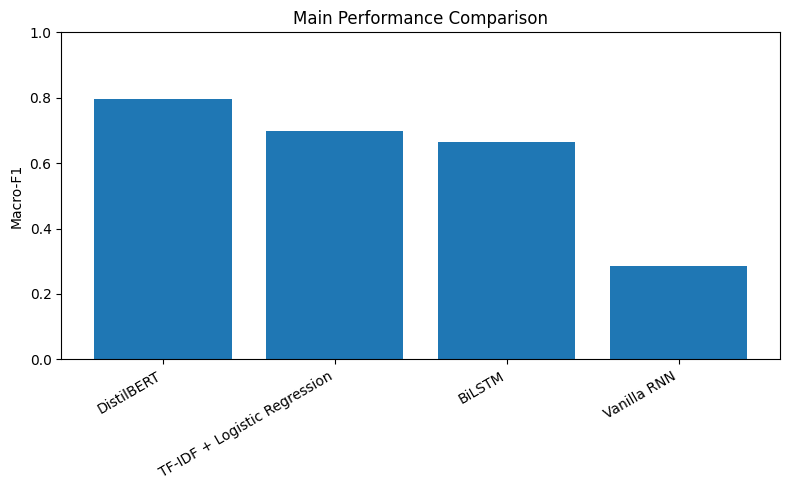

In [136]:
plt.figure(figsize=(8, 5))

plt.bar(
    performance_df["model"],
    performance_df["macro_f1"]
)

plt.ylabel("Macro-F1")
plt.title("Main Performance Comparison")
plt.xticks(rotation=30, ha="right")
plt.ylim(0, 1)
plt.tight_layout()
plt.savefig("main_performance_comparison_macro_f1.png", dpi=300)
plt.show()

## Confusion Matrices

In [118]:
def plot_confusion_matrix_for_model(model_name, y_true, y_pred, label_names):
    cm = confusion_matrix(y_true, y_pred)

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=label_names
    )

    fig, ax = plt.subplots(figsize=(6, 5))
    disp.plot(
        ax=ax,
        values_format="d",
        cmap=None,
        colorbar=False
    )

    plt.title(f"Confusion Matrix: {model_name}")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

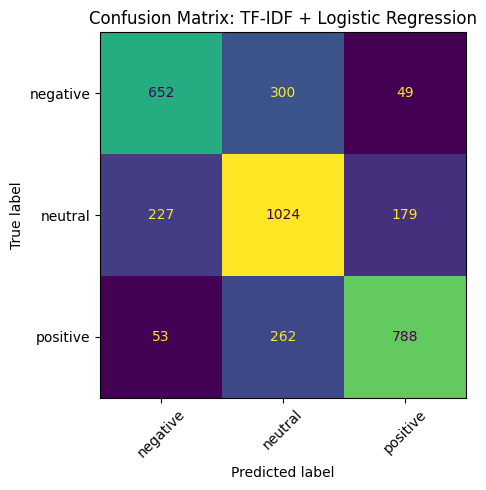

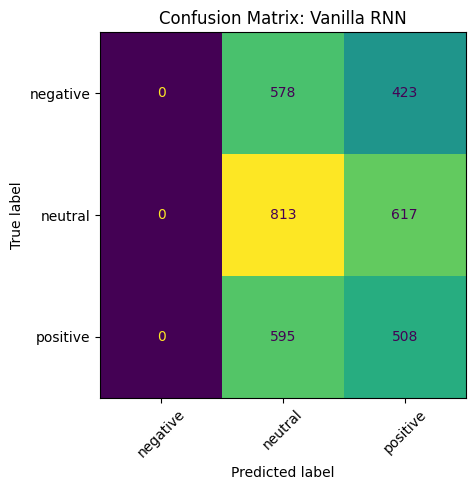

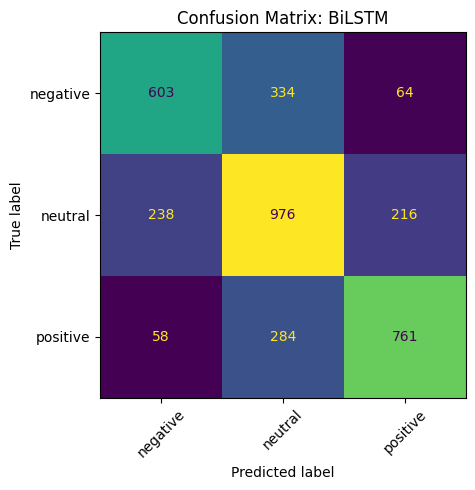

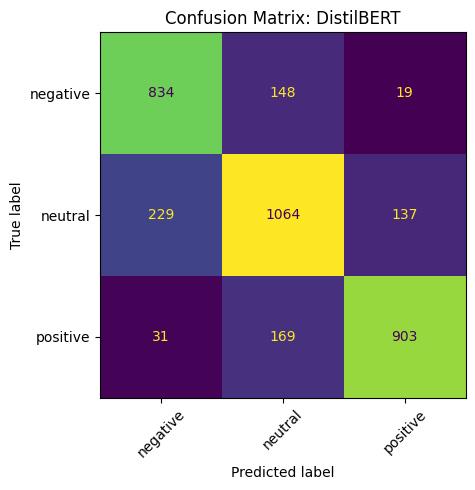

In [121]:
for model_name, result in all_results.items():
    plot_confusion_matrix_for_model(
        model_name,
        result["y_true"],
        result["y_pred"],
        label_names
    )

In [122]:
def save_confusion_matrix(model_name, y_true, y_pred, label_names):
    cm = confusion_matrix(y_true, y_pred)

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=label_names
    )

    fig, ax = plt.subplots(figsize=(6, 5))
    disp.plot(
        ax=ax,
        values_format="d",
        cmap=None,
        colorbar=False
    )

    plt.title(f"Confusion Matrix: {model_name}")
    plt.xticks(rotation=45)
    plt.tight_layout()

    safe_name = model_name.lower().replace(" ", "_").replace("+", "plus")
    filename = f"confusion_matrix_{safe_name}.png"

    plt.savefig(filename, dpi=300)
    plt.close()

    return filename

In [123]:
saved_cm_files = []

for model_name, result in all_results.items():
    filename = save_confusion_matrix(
        model_name,
        result["y_true"],
        result["y_pred"],
        label_names
    )

    saved_cm_files.append(filename)

saved_cm_files

['confusion_matrix_tf-idf_plus_logistic_regression.png',
 'confusion_matrix_vanilla_rnn.png',
 'confusion_matrix_bilstm.png',
 'confusion_matrix_distilbert.png']

## Inference Time Comparison

In [125]:
def time_function(fn, num_runs=5):
    times = []

    for _ in range(num_runs):
        start = time.perf_counter()
        fn()
        end = time.perf_counter()

        times.append(end - start)

    return {
        "mean_seconds": np.mean(times),
        "std_seconds": np.std(times),
        "min_seconds": np.min(times),
        "max_seconds": np.max(times)
    }

In [126]:
def run_tfidf_inference():
    _ = predict_tfidf_logreg(
        best_tfidf_logreg_model,
        test_df
    )

tfidf_time = time_function(run_tfidf_inference, num_runs=5)

In [128]:
def run_rnn_inference():
    _ = predict_torch_model(
        rnn_model,
        test_loader,
        device
    )

rnn_time = time_function(run_rnn_inference, num_runs=5)

In [129]:
def run_bilstm_inference():
    _ = predict_torch_model(
        bilstm_model,
        test_loader,
        device
    )

bilstm_time = time_function(run_bilstm_inference, num_runs=5)

In [130]:
def run_distilbert_inference():
    _ = predict_distilbert(
        distilbert_model,
        distilbert_tokenizer,
        test_df,
        batch_size=32,
        max_length=128
    )

distilbert_time = time_function(run_distilbert_inference, num_runs=5)

In [131]:
num_test_examples = len(test_df)

timing_rows = []

for model_name, timing in [
    ("TF-IDF + Logistic Regression", tfidf_time),
    ("Vanilla RNN", rnn_time),
    ("BiLSTM", bilstm_time),
    ("DistilBERT", distilbert_time)
]:
    mean_seconds = timing["mean_seconds"]

    timing_rows.append({
        "model": model_name,
        "mean_total_seconds": mean_seconds,
        "std_seconds": timing["std_seconds"],
        "seconds_per_example": mean_seconds / num_test_examples,
        "examples_per_second": num_test_examples / mean_seconds
    })

inference_time_df = pd.DataFrame(timing_rows)

inference_time_df = inference_time_df.sort_values(
    by="examples_per_second",
    ascending=False
).reset_index(drop=True)

inference_time_df

,model,mean_total_seconds,std_seconds,seconds_per_example,examples_per_second
0,TF-IDF + Logistic Regression,0.039430,0.000425,0.000011,89626.065902
1,Vanilla RNN,0.148919,0.002172,0.000042,23730.950872
2,BiLSTM,0.216676,0.002960,0.000061,16310.048593
3,DistilBERT,1.898793,0.014583,0.000537,1861.182108


In [132]:
inference_time_df.to_csv("inference_time_comparison.csv", index=False)

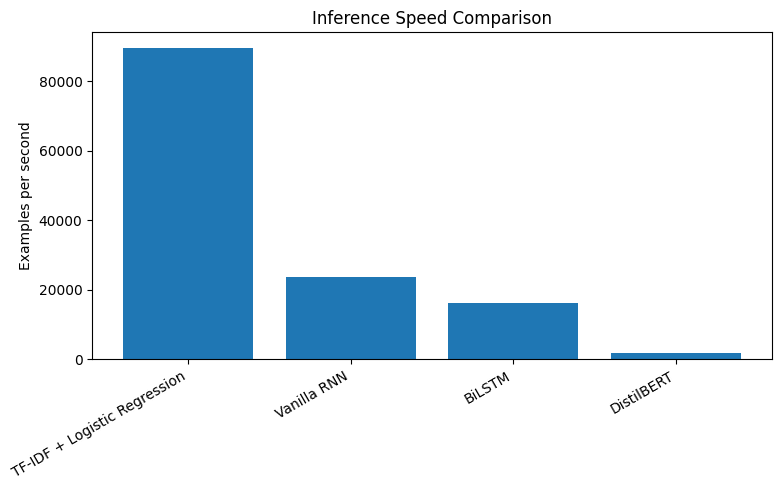

In [139]:
plt.figure(figsize=(8, 5))

plt.bar(
    inference_time_df["model"],
    inference_time_df["examples_per_second"]
)

plt.ylabel("Examples per second")
plt.title("Inference Speed Comparison")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig("inference_speed_comparison.png", dpi=300)
plt.show()